# Installation
#### Dataset and Python Dependencies if necessary

In [1]:
#! pip install -r requirements.txt

import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import glob

/Users/circus/repos/TFG_Chantada/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def download_dataset():
    # Solo descarga los ficheros al disco
    path = kagglehub.dataset_download(
        "urvishahir/minecraft-block-textures-dataset"
    )
    print(path)  # ruta local al dataset

# Print the images of ores

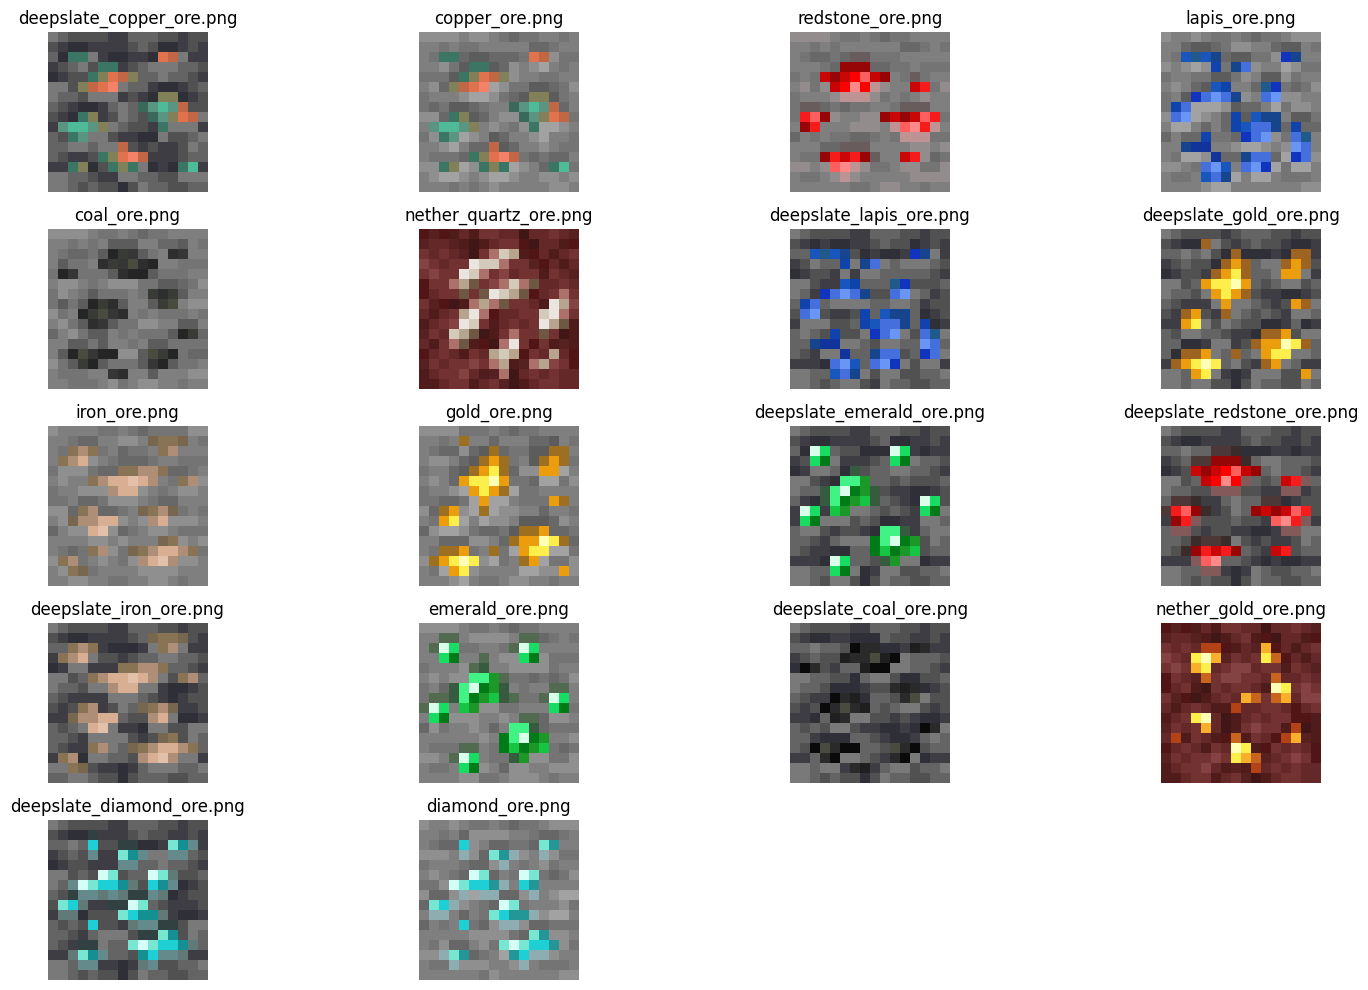

In [5]:
def return_ores():
    # Download and get the dataset path
    folder = "api_test/dataset/3/minecraft_block_textures/images"
    if not os.path.exists(folder):
        path = kagglehub.dataset_download("urvishahir/minecraft-block-textures-dataset")
    
    minecraft_blocks_path = os.path.join(path, "minecraft_block_textures/images")
    
    # Buscar todos los archivos que terminen en _ore.png
    ore_pattern = os.path.join(minecraft_blocks_path, "*_ore.png")
    ore_images = glob.glob(ore_pattern)
    
    return ore_images

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_ores(ore_paths):
    # Configuramos una cuadrícula (ej: 4 columnas)
    cols = 4
    rows = (len(ore_paths) // cols) + 1
    
    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(ore_paths):
        img = mpimg.imread(img_path)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

ores = return_ores()
plot_ores(ores)

# Transformaciones

Ya que tenemos solo una imagen por dataset, vamos a intentar aplicar transformaciones. Ademas, deberia mejorar el rendimiento del modelo, ya que $\textit{casi nunca}$ va a ver los bloques de frente perfectamente. Por ello modificaciones de zoom, rotacion, saturacion (y practicamente cualquier transformación) debería ayudar al rendimiento. 

In [8]:
import albumentations as A

original_ores = ores # Podemos usar la lista original ya que solo estamos testeando

transform = A.Compose([
    A.RandomBrightnessContrast(p=0.5), # Simula cambios de luz en cuevas
    A.Perspective(scale=(0.05, 0.1), p=0.5), # Simula diferentes ángulos de visión
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
])

/Users/circus/repos/TFG_Chantada/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
import cv2

N_VARIACIONES = 20
augmented_images = []

for ore_path in ores:
    base_image = cv2.imread(ore_path)
    base_image = cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB)
    
    for _ in range(N_VARIACIONES):
        augmented = transform(image=base_image)['image']
        augmented_images.append(augmented)

def display_augmented_images(images, cols=4):
    rows = (len(images) // cols) + 1
    plt.figure(figsize=(15, 10))
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [18]:
img = cv2.imread(original_ores[1])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("size: ", img.shape)

size:  (16, 16, 3)


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

def crear_modelo_simple(num_clases, input_shape=(16, 16, 3)):
    model = models.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),  # 16→8
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),  # 8→4
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),  # 4→4
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_clases, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Ejemplo de uso:
# Si tienes 8 tipos de minerales (ores)
model = crear_modelo_simple(num_clases=18)
model.summary()

/Users/circus/repos/TFG_Chantada/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,354 (352.95 KB)

 Trainable params: 90,354 (352.95 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

# Preparar labels para las imágenes augmentadas
# Cada imagen original tiene N_VARIACIONES transformaciones
labels = []
for idx, ore_path in enumerate(ores):
    # Cada mineral tiene N_VARIACIONES imágenes augmentadas
    labels.extend([idx] * N_VARIACIONES)

labels = np.array(labels)

# Convertir lista de imágenes a numpy array
X = np.array(augmented_images)

# Normalizar las imágenes (píxeles de 0-255 a 0-1)
X = X.astype('float32') / 255.0

# Dividir en conjunto de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Conjunto de validación: {X_val.shape[0]} imágenes")
print(f"Shape de las imágenes: {X_train.shape[1:]}")
print(f"Número de clases: {len(ores)}")
print(f"Distribución de clases en entrenamiento: {np.bincount(y_train)}")

Conjunto de entrenamiento: 288 imágenes
Conjunto de validación: 72 imágenes
Shape de las imágenes: (16, 16, 3)
Número de clases: 18
Distribución de clases en entrenamiento: [16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16]


In [23]:
# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)



Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0660 - loss: 2.8813 - val_accuracy: 0.2222 - val_loss: 2.8484
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1597 - loss: 2.8278 - val_accuracy: 0.1528 - val_loss: 2.7726
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1736 - loss: 2.7297 - val_accuracy: 0.1667 - val_loss: 2.6052
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1632 - loss: 2.5529 - val_accuracy: 0.1806 - val_loss: 2.4080
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1701 - loss: 2.4725 - val_accuracy: 0.2917 - val_loss: 2.2118
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2361 - loss: 2.2488 - val_accuracy: 0.4167 - val_loss: 2.0349
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3056 - loss: 2.0945 - val_accuracy: 0.4167 - val_loss: 1.8320
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2708 - loss: 2.0659 - val_accuracy: 0.4444 - val_loss: 1.7417
Epoch 9

In [31]:
# Use one of the existing ore images for testing
test_image = cv2.imread(ores[2])  # diamond_ore.png
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
test_image = cv2.resize(test_image, (16, 16))

prediction = model.predict(np.expand_dims(test_image.astype('float32') / 255.0, axis=0))
predicted_class = np.argmax(prediction)
predicted_ore = os.path.basename(ores[predicted_class])

print(f"Predicted class: {predicted_class}")
print(f"Predicted ore: {predicted_ore}")
print(f"Confidence: {prediction[0][predicted_class]:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted class: 2
Predicted ore: redstone_ore.png
Confidence: 97.81%
